# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement

* This analysis seeks to identify if there is a possible correlation between obesity and cancer related deaths. We will compare the national age adjusted death rate from the years 2011 through 2017. Also, we will identify which states have the highest death rate for cancer and which states have the highest rate of obesity.

Finding the right datasets can be time-consuming. Here we provide you with a list of websites to start with. But we encourage you to explore more websites and find the data that interests you.

* Google Dataset Search https://datasetsearch.research.google.com/
* The U.S. Government’s open data https://data.gov/
* UCI Machine Learning Repository https://archive.ics.uci.edu/ml/index.php


### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

In [1]:
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Allows all columns in the datasets to be displayed
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

#### **Dataset 1**

Type: API endpoint

Method: The data was obtained using the API available at https://data.cdc.gov/NCHS/NCHS-Leading-Causes-of-Death-United-States/bi63-dtpu/about_data. The API only allowed 1,000 rows to be downloaded per query, so I created a loop to query the data.
* Code resource: https://pythonmania.org/how-to-use-requests-module-in-python-with-examples/

Dataset variables:

*   *Variable 1: year - The year the data is collected from. 
*   *Variable 2: _113_cause_name - Long description of the disease state.
*   *Variable 3: cause_name - Short description of disease state.
*   *Variable 4: deaths - number of deaths by cause.
*   *Variable 5: aadr - age adjusted death rate - number of deaths by cause per 100,000 people.

In [3]:
#FILL IN 1st data gathering and loading method

url = "https://data.cdc.gov/resource/bi63-dtpu.json"
limit = 1000
offset = 0
total_rows = 10868

all_data = []

while offset < total_rows:
    params = {
        "$limit": limit,
        "$offset": offset
    }
    response = requests.get(url, params=params)
    data = response.json()
    all_data.extend(data)
    offset += limit

cancer_df = pd.DataFrame(all_data)
cancer_df.to_csv("cdc_data.csv", index=False)

#### Dataset 2

Type: CSV File

Method: Dataset is obtained as a CSV download from https://catalog.data.gov/dataset/nutrition-physical-activity-and-obesity-behavioral-risk-factor-surveillance-system. 

Dataset variables: (Due to there being 33 variables, I will only state the variables that I intend to use for this analysis.)

*   *Variable 1: Data_Value_Unit - year the data was collected.
*   *Variable 2: LocationDesc - state in the US where the data was collected from.
*   *Variable 3: ClassID - code for Class, we are mostly interested in the ClassID of OWS meaning Obesity/Weight Status.
*   *Variable 4: StratificationCategoryId1 - indicates the stratification category, such as race, income, or age. We are most interested in code      *    'OVR' indicating overweight.
*   *Variable 5: QuestionID - indicates categorical questions. We are most interested in Q036, indicating 'Percent of adults aged 18 years and older *    who have obesity.
*   *Variable 6: Data_Value - the number percentage of adults aged 18 years and older who have obesity.

In [4]:
#FILL IN 2nd data gathering and loading method

obesity_data = pd.read_csv('Nutrition__Physical_Activity__and_Obesity_-_Behavioral_Risk_Factor_Surveillance_System.csv')

Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [5]:
#Optional: store the raw data in your local data store

## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

# Assessing cleaned_cancer dataframe

In [6]:
#FILL IN - Inspecting the dataframe visually
cleaned_cancer = cancer_df.copy()
cleaned_cancer.head()

,year,_113_cause_name,cause_name,state,deaths,aadr
0,2012,"Nephritis, nephrotic syndrome and nephrosis (N...",Kidney disease,Vermont,21,2.6
1,2017,"Nephritis, nephrotic syndrome and nephrosis (N...",Kidney disease,Vermont,29,3.3
2,2016,"Nephritis, nephrotic syndrome and nephrosis (N...",Kidney disease,Vermont,30,3.7
3,2013,"Nephritis, nephrotic syndrome and nephrosis (N...",Kidney disease,Vermont,30,3.8
4,2000,"Intentional self-harm (suicide) (*U03,X60-X84,...",Suicide,District of Columbia,23,3.8


In [7]:
cleaned_cancer.tail()

,year,_113_cause_name,cause_name,state,deaths,aadr
10863,2001,All Causes,All causes,District of Columbia,5951,1049.9
10864,2002,All Causes,All causes,Mississippi,28853,1051.6
10865,2000,All Causes,All causes,Mississippi,28654,1051.9
10866,2000,All Causes,All causes,District of Columbia,6001,1061.2
10867,1999,All Causes,All causes,District of Columbia,6076,1087.3


In [8]:
cleaned_cancer.sample(20)

,year,_113_cause_name,cause_name,state,deaths,aadr
968,2007,"Intentional self-harm (suicide) (*U03,X60-X84,...",Suicide,Alabama,592,12.4
6996,2000,Chronic lower respiratory diseases (J40-J47),CLRD,North Carolina,3699,48.9
6848,2013,Cerebrovascular diseases (I60-I69),Stroke,Arkansas,1637,47.6
9880,2016,All Causes,All causes,Hawaii,10913,572.0
8286,2017,"Diseases of heart (I00-I09,I11,I13,I20-I51)",Heart disease,Wisconsin,11860,157.6
887,2010,"Intentional self-harm (suicide) (*U03,X60-X84,...",Suicide,Iowa,372,12.1
9532,1999,Malignant neoplasms (C00-C97),Cancer,Ohio,25233,215.4
5534,2016,Cerebrovascular diseases (I60-I69),Stroke,California,15680,36.9
6793,2000,"Accidents (unintentional injuries) (V01-X59,Y8...",Unintentional injuries,Alabama,2093,47.0
3539,2002,Alzheimer's disease (G30),Alzheimer's disease,Minnesota,1192,22.3


In [9]:
#FILL IN - Inspecting the dataframe programmatically
# There are no null values.
cleaned_cancer.isnull().sum()


year               0
_113_cause_name    0
cause_name         0
state              0
deaths             0
aadr               0
dtype: int64

In [10]:
# There are no duplicate values.
cleaned_cancer.duplicated().sum()

np.int64(0)

In [11]:
cleaned_cancer.describe()

,year,_113_cause_name,cause_name,state,deaths,aadr
count,10868,10868,10868,10868,10868,10868
unique,19,11,11,52,5964,2490
top,2012,"Nephritis, nephrotic syndrome and nephrosis (N...",Kidney disease,Vermont,343,19.2
freq,572,988,988,209,15,40


In [12]:
#FILL IN - Inspecting the dataframe visually
cancer_columns = cleaned_cancer.columns
cancer_columns

Index(['year', '_113_cause_name', 'cause_name', 'state', 'deaths', 'aadr'], dtype='object')

In [13]:
cleaned_cancer['cause_name'].unique()

array(['Kidney disease', 'Suicide', 'Influenza and pneumonia',
       "Alzheimer's disease", 'Diabetes', 'CLRD',
       'Unintentional injuries', 'Stroke', 'Heart disease', 'Cancer',
       'All causes'], dtype=object)

In [14]:
cancer_states = cleaned_cancer['state'].unique()
cancer_states.sort()
print(cancer_states)

['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida' 'Georgia'
 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky'
 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota'
 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada' 'New Hampshire'
 'New Jersey' 'New Mexico' 'New York' 'North Carolina' 'North Dakota'
 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Rhode Island' 'South Carolina'
 'South Dakota' 'Tennessee' 'Texas' 'United States' 'Utah' 'Vermont'
 'Virginia' 'Washington' 'West Virginia' 'Wisconsin' 'Wyoming']


In [15]:
#FILL IN - Inspecting the dataframe programmatically
# Make sure both the cancer and obesity dataframes have the same state values to merge. 
num_cancer_states = len(cancer_states)
print(f'Number of US States in the cleaned_cancer dataframe: {num_cancer_states}')

Number of US States in the cleaned_cancer dataframe: 52


In [16]:
# Make sure that both the cancer and obesity dataframes have the same date range.
cleaned_cancer['year'].unique()

array(['2012', '2017', '2016', '2013', '2000', '2014', '2009', '2015',
       '2011', '2001', '1999', '2006', '2002', '2003', '2008', '2005',
       '2004', '2007', '2010'], dtype=object)

In [17]:
# To DO: Need to change aadr to a float and year to date format.
cleaned_cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10868 entries, 0 to 10867
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   year             10868 non-null  object
 1   _113_cause_name  10868 non-null  object
 2   cause_name       10868 non-null  object
 3   state            10868 non-null  object
 4   deaths           10868 non-null  object
 5   aadr             10868 non-null  object
dtypes: object(6)
memory usage: 509.6+ KB


In [18]:
# Finding the number of rows and columns.
cleaned_cancer_shape = cleaned_cancer.shape
print(f'Number of rows in cleaned_cancer dataframe: {cleaned_cancer_shape[0]}')
print(f'Number of columns in cleaned_cancer dataframe: {cleaned_cancer_shape[1]}')

Number of rows in cleaned_cancer dataframe: 10868
Number of columns in cleaned_cancer dataframe: 6



### Quality Issue 1: There are 15 columns with Null or missing values. In the cleaning step I will try to address the issue first by filtering out columns that I don't want to use in my analysis. If there are any other Null or missing values after the aforementioned, I will address them.

In [19]:
cleaned_obesity = obesity_data.copy()

In [20]:
#FILL IN - Inspecting the dataframe visually
cleaned_obesity.head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Alt,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,Total,Age(years),Education,Gender,Income,Race/Ethnicity,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
0,2011,2011,AK,Alaska,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2011.0,Value,23.3,23.3,NaN,NaN,16.1,32.4,128.0,NaN,NaN,NaN,NaN,NaN,2 or more races,"(64.845079957001, -147.722059036)",OWS,OWS1,Q036,VALUE,2,Race/Ethnicity,2 or more races,RACE,RACE2PLUS
1,2011,2011,AK,Alaska,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2011.0,Value,35.5,35.5,NaN,NaN,22.7,50.9,63.0,NaN,NaN,NaN,NaN,NaN,Other,"(64.845079957001, -147.722059036)",OWS,OWS1,Q036,VALUE,2,Race/Ethnicity,Other,RACE,RACEOTH
2,2011,2011,AK,Alaska,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who achieve at least 150 min...,2011.0,Value,21.7,21.7,NaN,NaN,19.1,24.6,1702.0,NaN,NaN,NaN,Female,NaN,NaN,"(64.845079957001, -147.722059036)",PA,PA1,Q044,VALUE,2,Gender,Female,GEN,FEMALE
3,2011,2011,AK,Alaska,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2011.0,Value,29.5,29.5,NaN,NaN,24.5,35.0,562.0,NaN,35 - 44,NaN,NaN,NaN,NaN,"(64.845079957001, -147.722059036)",OWS,OWS1,Q036,VALUE,2,Age (years),35 - 44,AGEYR,AGEYR3544
4,2011,2011,AK,Alaska,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2011.0,Value,33.5,33.5,NaN,NaN,26.2,41.7,377.0,NaN,NaN,NaN,NaN,"$15,000 - $24,999",NaN,"(64.845079957001, -147.722059036)",OWS,OWS1,Q037,VALUE,2,Income,"$15,000 - $24,999",INC,INC1525


In [21]:
cleaned_obesity.tail()

,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Alt,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,Total,Age(years),Education,Gender,Income,Race/Ethnicity,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
104267,2023,2023,WY,Wyoming,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-tim...,NaN,Value,31.7,31.7,NaN,NaN,28.5,35.2,1118.0,NaN,NaN,High school graduate,NaN,NaN,NaN,"(43.23554134300048, -108.10983035299967)",PA,PA1,Q047,VALUE,56,Education,High school graduate,EDU,EDUHSGRAD
104268,2023,2023,WY,Wyoming,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-tim...,NaN,Value,32.4,32.4,NaN,NaN,30.1,34.7,2231.0,NaN,65 or older,NaN,NaN,NaN,NaN,"(43.23554134300048, -108.10983035299967)",PA,PA1,Q047,VALUE,56,Age (years),65 or older,AGEYR,AGEYR65PLUS
104269,2023,2023,WY,Wyoming,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-tim...,NaN,Value,22.5,22.5,NaN,NaN,20.0,25.2,1677.0,NaN,NaN,NaN,NaN,Data not reported,NaN,"(43.23554134300048, -108.10983035299967)",PA,PA1,Q047,VALUE,56,Income,Data not reported,INC,INCNR
104270,2023,2023,WY,Wyoming,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in muscle-strengt...,NaN,Value,35.6,35.6,NaN,NaN,27.5,44.8,154.0,NaN,NaN,Less than high school,NaN,NaN,NaN,"(43.23554134300048, -108.10983035299967)",PA,PA1,Q046,VALUE,56,Education,Less than high school,EDU,EDUHS
104271,2023,2023,WY,Wyoming,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-tim...,NaN,Value,34.7,34.7,NaN,NaN,30.7,39.0,707.0,NaN,55 - 64,NaN,NaN,NaN,NaN,"(43.23554134300048, -108.10983035299967)",PA,PA1,Q047,VALUE,56,Age (years),55 - 64,AGEYR,AGEYR5564


In [22]:
cleaned_obesity.sample(10)

,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Alt,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,Total,Age(years),Education,Gender,Income,Race/Ethnicity,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
37542,2015,2015,RI,Rhode Island,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2015.0,Value,NaN,NaN,~,Data not available because sample size is insu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hawaiian/Pacific Islander,"(41.708280193, -71.522470314)",OWS,OWS1,Q037,VALUE,44,Race/Ethnicity,Hawaiian/Pacific Islander,RACE,RACEHPI
40049,2016,2016,AL,Alabama,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2016.0,Value,36.9,36.9,NaN,NaN,23.7,52.5,76.0,NaN,NaN,NaN,NaN,NaN,Hispanic,"(32.840571122, -86.631860762)",OWS,OWS1,Q037,VALUE,1,Race/Ethnicity,Hispanic,RACE,RACEHIS
66828,2019,2019,IL,Illinois,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who achieve at least 150 min...,2019.0,Value,NaN,NaN,~,Data not available because sample size is insu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hawaiian/Pacific Islander,"(40.48501028300046, -88.99771017799969)",PA,PA1,Q044,VALUE,17,Race/Ethnicity,Hawaiian/Pacific Islander,RACE,RACEHPI
38555,2015,2015,US,National,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who achieve at least 150 min...,2015.0,Value,51.3,51.3,NaN,NaN,49.2,53.4,7783.0,NaN,NaN,NaN,NaN,NaN,Asian,NaN,PA,PA1,Q043,VALUE,59,Race/Ethnicity,Asian,RACE,RACEASN
4091,2011,2011,MD,Maryland,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2011.0,Value,33.3,33.3,NaN,NaN,29.3,37.7,831.0,NaN,25 - 34,NaN,NaN,NaN,NaN,"(39.290580964, -76.609260111)",OWS,OWS1,Q037,VALUE,24,Age (years),25 - 34,AGEYR,AGEYR2534
18066,2013,2013,KY,Kentucky,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2013.0,Value,34.3,34.3,NaN,NaN,31.9,36.9,2815.0,NaN,NaN,Some college or technical school,NaN,NaN,NaN,"(37.645970271, -84.774971048)",OWS,OWS1,Q036,VALUE,21,Education,Some college or technical school,EDU,EDUCOTEC
24184,2013,2013,WA,Washington,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who achieve at least 300 min...,2013.0,Value,37.7,37.7,NaN,NaN,33.4,42.1,972.0,NaN,NaN,NaN,NaN,"$25,000 - $34,999",NaN,"(47.522278629, -120.47001079)",PA,PA1,Q045,VALUE,53,Income,"$25,000 - $34,999",INC,INC2535
76572,2019,2019,WY,Wyoming,BRFSS,Fruits and Vegetables,Fruits and Vegetables - Behavior,Percent of adults who report consuming vegetab...,2019.0,Value,17.7,17.7,NaN,NaN,13.4,23.1,558.0,NaN,NaN,NaN,NaN,"$35,000 - $49,999",NaN,"(43.23554134300048, -108.10983035299967)",FV,FV1,Q019,VALUE,56,Income,"$35,000 - $49,999",INC,INC3550
94093,2023,2023,AZ,Arizona,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,30.5,30.5,NaN,NaN,25.8,35.5,895.0,NaN,NaN,NaN,NaN,"$15,000 - $24,999",NaN,"(34.865970280000454, -111.76381127699972)",OWS,OWS1,Q037,VALUE,4,Income,"$15,000 - $24,999",INC,INC1525
89039,2022,2022,AL,Alabama,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,43.2,43.2,NaN,NaN,37.8,48.6,477.0,NaN,35 - 44,NaN,NaN,NaN,NaN,"(32.84057112200048, -86.63186076199969)",OWS,OWS1,Q036,VALUE,1,Age (years),35 - 44,AGEYR,AGEYR3544


In [23]:
#FILL IN - Inspecting the dataframe programmatically
cleaned_obesity.isnull().sum()

YearStart                          0
YearEnd                            0
LocationAbbr                       0
LocationDesc                       0
Datasource                         0
Class                              0
Topic                              0
Question                           0
Data_Value_Unit                15400
Data_Value_Type                    0
Data_Value                     10767
Data_Value_Alt                 10767
Data_Value_Footnote_Symbol     93505
Data_Value_Footnote            93505
Low_Confidence_Limit           10767
High_Confidence_Limit          10767
Sample_Size                    10767
Total                         100548
Age(years)                     81928
Education                      89376
Gender                         96824
Income                         78204
Race/Ethnicity                 74480
GeoLocation                     1932
ClassID                            0
TopicID                            0
QuestionID                         0
D

In [24]:
# Function for finding percent of missing values for each column.
def print_pct_missing_values(df):
    df_shape = df.shape
    missing_values = df.isnull().sum()

    pct_missing = []
    for col, val in missing_values.items():
        pct = val / df_shape[0]
        pct_missing.append((col, pct))

    # Sort the list by the percentage of missing values
    pct_missing.sort(key=lambda x: x[1], reverse=False)

    for col, pct in pct_missing:
        print(f"{col}: {pct:.2%}")

In [25]:
print_pct_missing_values(cleaned_obesity)

YearStart: 0.00%
YearEnd: 0.00%
LocationAbbr: 0.00%
LocationDesc: 0.00%
Datasource: 0.00%
Class: 0.00%
Topic: 0.00%
Question: 0.00%
Data_Value_Type: 0.00%
ClassID: 0.00%
TopicID: 0.00%
QuestionID: 0.00%
DataValueTypeID: 0.00%
LocationID: 0.00%
StratificationCategory1: 0.00%
Stratification1: 0.00%
StratificationCategoryId1: 0.00%
StratificationID1: 0.00%
GeoLocation: 1.85%
Data_Value: 10.33%
Data_Value_Alt: 10.33%
Low_Confidence_Limit: 10.33%
High_Confidence_Limit : 10.33%
Sample_Size: 10.33%
Data_Value_Unit: 14.77%
Race/Ethnicity: 71.43%
Income: 75.00%
Age(years): 78.57%
Education: 85.71%
Data_Value_Footnote_Symbol: 89.67%
Data_Value_Footnote: 89.67%
Gender: 92.86%
Total: 96.43%



### Quality Issue 2: There are fields such as YearStart, YearEnd, Data_Value_Unit, Class, Topic and Question that seem to duplicate the same values throughout the cleaned_obesity table. These columns will be removed before conducting the analysis.

In [26]:
#FILL IN - Inspecting the dataframe visually
cleaned_obesity.sample(10)

,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Alt,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,Total,Age(years),Education,Gender,Income,Race/Ethnicity,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
19844,2013,2013,MT,Montana,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in muscle-strengt...,2013.0,Value,24.4,24.4,NaN,NaN,19.8,29.8,647.0,NaN,NaN,Less than high school,NaN,NaN,NaN,"(47.066528972, -109.424420645)",PA,PA1,Q046,VALUE,30,Education,Less than high school,EDU,EDUHS
13477,2012,2012,RI,Rhode Island,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-tim...,2012.0,Value,20.0,20.0,NaN,NaN,10.5,34.9,55.0,NaN,NaN,NaN,NaN,NaN,Asian,"(41.708280193, -71.522470314)",PA,PA1,Q047,VALUE,44,Race/Ethnicity,Asian,RACE,RACEASN
35500,2015,2015,NH,New Hampshire,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who achieve at least 150 min...,2015.0,Value,NaN,NaN,~,Data not available because sample size is insu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Non-Hispanic Black,"(43.655950113, -71.50036092)",PA,PA1,Q043,VALUE,33,Race/Ethnicity,Non-Hispanic Black,RACE,RACEBLK
17171,2013,2013,ID,Idaho,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-tim...,2013.0,Value,25.2,25.2,NaN,NaN,20.9,30.0,670.0,NaN,NaN,NaN,NaN,"$25,000 - $34,999",NaN,"(43.682630005, -114.363730042)",PA,PA1,Q047,VALUE,16,Income,"$25,000 - $34,999",INC,INC2535
89,2011,2011,AK,Alaska,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in muscle-strengt...,2011.0,Value,51.9,51.9,NaN,NaN,43.4,60.4,211.0,NaN,18 - 24,NaN,NaN,NaN,NaN,"(64.845079957001, -147.722059036)",PA,PA1,Q046,VALUE,2,Age (years),18 - 24,AGEYR,AGEYR1824
10740,2012,2012,CT,Connecticut,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2012.0,Value,27.3,27.3,NaN,NaN,23.7,31.3,956.0,NaN,NaN,NaN,NaN,"$35,000 - $49,999",NaN,"(41.56266102, -72.649840952)",OWS,OWS1,Q036,VALUE,9,Income,"$35,000 - $49,999",INC,INC3550
77278,2020,2020,DC,District of Columbia,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2020.0,Value,32.7,32.7,NaN,NaN,27.3,38.6,435.0,NaN,NaN,High school graduate,NaN,NaN,NaN,"(38.89037138500049, -77.03196112699965)",OWS,OWS1,Q036,VALUE,11,Education,High school graduate,EDU,EDUHSGRAD
81534,2021,2021,AR,Arkansas,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-tim...,2021.0,Value,40.0,40.0,NaN,NaN,37.7,42.5,2884.0,NaN,65 or older,NaN,NaN,NaN,NaN,"(34.74865012400045, -92.27449074299966)",PA,PA1,Q047,VALUE,5,Age (years),65 or older,AGEYR,AGEYR65PLUS
60336,2018,2018,ME,Maine,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2018.0,Value,39.7,39.7,NaN,NaN,36.9,42.6,2275.0,NaN,55 - 64,NaN,NaN,NaN,NaN,"(45.254228894000505, -68.98503133599962)",OWS,OWS1,Q037,VALUE,23,Age (years),55 - 64,AGEYR,AGEYR5564
34501,2015,2015,MS,Mississippi,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-tim...,2015.0,Value,48.5,48.5,NaN,NaN,43.3,53.7,768.0,NaN,NaN,Less than high school,NaN,NaN,NaN,"(32.745510099, -89.538030825)",PA,PA1,Q047,VALUE,28,Education,Less than high school,EDU,EDUHS


In [27]:
#FILL IN - Inspecting the dataframe programmatically
cleaned_obesity.duplicated().sum()

np.int64(0)

In [28]:
cleaned_obesity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104272 entries, 0 to 104271
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   YearStart                   104272 non-null  int64  
 1   YearEnd                     104272 non-null  int64  
 2   LocationAbbr                104272 non-null  object 
 3   LocationDesc                104272 non-null  object 
 4   Datasource                  104272 non-null  object 
 5   Class                       104272 non-null  object 
 6   Topic                       104272 non-null  object 
 7   Question                    104272 non-null  object 
 8   Data_Value_Unit             88872 non-null   float64
 9   Data_Value_Type             104272 non-null  object 
 10  Data_Value                  93505 non-null   float64
 11  Data_Value_Alt              93505 non-null   float64
 12  Data_Value_Footnote_Symbol  10767 non-null   object 
 13  Data_Value_Foo

In [29]:
cleaned_obesity.describe()

,YearStart,YearEnd,Data_Value_Unit,Data_Value,Data_Value_Alt,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,LocationID
count,104272.000000,104272.000000,88872.000000,93505.000000,93505.000000,93505.000000,93505.000000,93505.000000,104272.000000
mean,2017.006176,2017.006176,2016.019534,31.849359,31.849359,27.452834,36.803022,3623.035260,31.053706
std,3.734882,3.734882,3.120714,10.417933,10.417933,10.204503,11.343284,18561.958269,17.605859
min,2011.000000,2011.000000,2011.000000,0.900000,0.900000,0.300000,3.000000,50.000000,1.000000
25%,2014.000000,2014.000000,2013.000000,24.900000,24.900000,20.400000,29.200000,499.000000,17.000000
50%,2017.000000,2017.000000,2016.000000,31.700000,31.700000,27.300000,36.500000,1085.000000,30.000000
75%,2020.000000,2020.000000,2019.000000,37.500000,37.500000,33.400000,42.900000,2397.000000,45.000000
max,2023.000000,2023.000000,2021.000000,85.300000,85.300000,74.700000,92.400000,476876.000000,78.000000


### Tidiness Issue 1: In the clean_cancer dataframe there are 52 values for states, but in the cleaned_obesity dataframe there are 55 states, designated under the column LocationDesc. This will have to be corrected to make sure the two tables can be merged for analysis.


In [30]:
#FILL IN - Inspecting the dataframe visually
cleaned_obesity.head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Alt,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,Total,Age(years),Education,Gender,Income,Race/Ethnicity,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
0,2011,2011,AK,Alaska,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2011.0,Value,23.3,23.3,NaN,NaN,16.1,32.4,128.0,NaN,NaN,NaN,NaN,NaN,2 or more races,"(64.845079957001, -147.722059036)",OWS,OWS1,Q036,VALUE,2,Race/Ethnicity,2 or more races,RACE,RACE2PLUS
1,2011,2011,AK,Alaska,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2011.0,Value,35.5,35.5,NaN,NaN,22.7,50.9,63.0,NaN,NaN,NaN,NaN,NaN,Other,"(64.845079957001, -147.722059036)",OWS,OWS1,Q036,VALUE,2,Race/Ethnicity,Other,RACE,RACEOTH
2,2011,2011,AK,Alaska,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who achieve at least 150 min...,2011.0,Value,21.7,21.7,NaN,NaN,19.1,24.6,1702.0,NaN,NaN,NaN,Female,NaN,NaN,"(64.845079957001, -147.722059036)",PA,PA1,Q044,VALUE,2,Gender,Female,GEN,FEMALE
3,2011,2011,AK,Alaska,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2011.0,Value,29.5,29.5,NaN,NaN,24.5,35.0,562.0,NaN,35 - 44,NaN,NaN,NaN,NaN,"(64.845079957001, -147.722059036)",OWS,OWS1,Q036,VALUE,2,Age (years),35 - 44,AGEYR,AGEYR3544
4,2011,2011,AK,Alaska,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2011.0,Value,33.5,33.5,NaN,NaN,26.2,41.7,377.0,NaN,NaN,NaN,NaN,"$15,000 - $24,999",NaN,"(64.845079957001, -147.722059036)",OWS,OWS1,Q037,VALUE,2,Income,"$15,000 - $24,999",INC,INC1525


In [31]:
cleaned_obesity.sample(10)

,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Alt,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,Total,Age(years),Education,Gender,Income,Race/Ethnicity,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
84942,2021,2021,MS,Mississippi,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2021.0,Value,30.4,30.4,NaN,NaN,27.3,33.7,1455.0,NaN,NaN,NaN,NaN,NaN,Non-Hispanic Black,"(32.745510099000455, -89.53803082499968)",OWS,OWS1,Q037,VALUE,28,Race/Ethnicity,Non-Hispanic Black,RACE,RACEBLK
45607,2017,2017,CA,California,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who achieve at least 150 min...,2017.0,Value,55.9,55.9,NaN,NaN,52.5,59.2,1410.0,NaN,NaN,High school graduate,NaN,NaN,NaN,"(37.638640123, -120.999999538)",PA,PA1,Q043,VALUE,6,Education,High school graduate,EDU,EDUHSGRAD
90098,2022,2022,ID,Idaho,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,38.2,38.2,NaN,NaN,34.7,41.9,912.0,NaN,35 - 44,NaN,NaN,NaN,NaN,"(43.682630005000476, -114.3637300419997)",OWS,OWS1,Q036,VALUE,16,Age (years),35 - 44,AGEYR,AGEYR3544
82059,2021,2021,CT,Connecticut,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2021.0,Value,41.8,41.8,NaN,NaN,39.5,44.1,3587.0,NaN,NaN,NaN,Male,NaN,NaN,"(41.56266102000046, -72.64984095199964)",OWS,OWS1,Q037,VALUE,9,Gender,Male,GEN,MALE
59544,2018,2018,IA,Iowa,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2018.0,Value,NaN,NaN,~,Data not available because sample size is insu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hawaiian/Pacific Islander,"(42.46940091300047, -93.81649055599968)",OWS,OWS1,Q036,VALUE,19,Race/Ethnicity,Hawaiian/Pacific Islander,RACE,RACEHPI
40949,2016,2016,HI,Hawaii,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-tim...,2016.0,Value,29.3,29.3,NaN,NaN,23.1,36.5,300.0,NaN,NaN,NaN,NaN,NaN,Hawaiian/Pacific Islander,"(21.304850435, -157.857749403)",PA,PA1,Q047,VALUE,15,Race/Ethnicity,Hawaiian/Pacific Islander,RACE,RACEHPI
98274,2023,2023,MN,Minnesota,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-tim...,NaN,Value,28.9,28.9,NaN,NaN,26.9,31.0,5874.0,NaN,65 or older,NaN,NaN,NaN,NaN,"(46.35564873600049, -94.79420050299967)",PA,PA1,Q047,VALUE,27,Age (years),65 or older,AGEYR,AGEYR65PLUS
78781,2020,2020,MO,Missouri,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2020.0,Value,29.3,29.3,NaN,NaN,27.5,31.2,4505.0,NaN,NaN,NaN,Female,NaN,NaN,"(38.635790776000476, -92.56630005299968)",OWS,OWS1,Q037,VALUE,29,Gender,Female,GEN,FEMALE
72042,2019,2019,NY,New York,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2019.0,Value,37.2,37.2,NaN,NaN,34.3,40.2,1924.0,NaN,45 - 54,NaN,NaN,NaN,NaN,"(42.82700103200045, -75.54397042699964)",OWS,OWS1,Q037,VALUE,36,Age (years),45 - 54,AGEYR,AGEYR4554
42054,2016,2016,MO,Missouri,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2016.0,Value,35.6,35.6,NaN,NaN,33.8,37.4,6578.0,Total,NaN,NaN,NaN,NaN,NaN,"(38.635790776, -92.566300053)",OWS,OWS1,Q037,VALUE,29,Total,Total,OVR,OVERALL


In [32]:
#FILL IN - Inspecting the dataframe programmatically
obesity_states = cleaned_obesity['LocationDesc'].unique()
obesity_states.sort()
print(obesity_states)

['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida' 'Georgia'
 'Guam' 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky'
 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota'
 'Mississippi' 'Missouri' 'Montana' 'National' 'Nebraska' 'Nevada'
 'New Hampshire' 'New Jersey' 'New Mexico' 'New York' 'North Carolina'
 'North Dakota' 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Puerto Rico'
 'Rhode Island' 'South Carolina' 'South Dakota' 'Tennessee' 'Texas' 'Utah'
 'Vermont' 'Virgin Islands' 'Virginia' 'Washington' 'West Virginia'
 'Wisconsin' 'Wyoming']


In [33]:
# TO DO: Need to make sure the states match in the cleaned_cancer dataframe
num_obesity_states = len(obesity_states)
print(f'Number of US States in the cleaned_obesity dataframe: {num_obesity_states}')

Number of US States in the cleaned_obesity dataframe: 55


In [34]:
cancer_states = cleaned_cancer['state'].unique()
cancer_states.sort()
print(cancer_states)

['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida' 'Georgia'
 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky'
 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota'
 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada' 'New Hampshire'
 'New Jersey' 'New Mexico' 'New York' 'North Carolina' 'North Dakota'
 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Rhode Island' 'South Carolina'
 'South Dakota' 'Tennessee' 'Texas' 'United States' 'Utah' 'Vermont'
 'Virginia' 'Washington' 'West Virginia' 'Wisconsin' 'Wyoming']


In [35]:
# Make sure both the cancer and obesity dataframes have the same state values to merge. 
num_cancer_states = len(cancer_states)
print(f'Number of US States in the cleaned_cancer dataframe: {num_cancer_states}')

Number of US States in the cleaned_cancer dataframe: 52


### Tidiness Issue 2: The cleaned_cancer and cleaned_obesity table have a different range of values indicating the year. This will have to be corrected to merge the two tables.

In [36]:
#FILL IN - Inspecting the dataframe visually
cleaned_obesity.sample(10)

,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Alt,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,Total,Age(years),Education,Gender,Income,Race/Ethnicity,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
49362,2017,2017,LA,Louisiana,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2017.0,Value,45.5,45.5,NaN,NaN,29.0,63.1,66.0,NaN,NaN,NaN,NaN,NaN,American Indian/Alaska Native,"(31.312660644, -92.445680071)",OWS,OWS1,Q036,VALUE,22,Race/Ethnicity,American Indian/Alaska Native,RACE,RACENAA
44968,2017,2017,AL,Alabama,BRFSS,Fruits and Vegetables,Fruits and Vegetables - Behavior,Percent of adults who report consuming fruit l...,2017.0,Value,44.7,44.7,NaN,NaN,41.5,47.9,1769.0,NaN,NaN,Some college or technical school,NaN,NaN,NaN,"(32.840571122, -86.631860762)",FV,FV1,Q018,VALUE,1,Education,Some college or technical school,EDU,EDUCOTEC
41505,2016,2016,KY,Kentucky,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2016.0,Value,34.3,34.3,NaN,NaN,31.7,37.0,2718.0,NaN,NaN,Some college or technical school,NaN,NaN,NaN,"(37.645970271, -84.774971048)",OWS,OWS1,Q036,VALUE,21,Education,Some college or technical school,EDU,EDUCOTEC
39852,2015,2015,WY,Wyoming,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who achieve at least 300 min...,2015.0,Value,37.3,37.3,NaN,NaN,31.5,43.4,769.0,NaN,NaN,NaN,NaN,Data not reported,NaN,"(43.235541343, -108.109830353)",PA,PA1,Q045,VALUE,56,Income,Data not reported,INC,INCNR
88044,2021,2021,VI,Virgin Islands,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2021.0,Value,39.5,39.5,NaN,NaN,27.6,52.7,192.0,NaN,NaN,NaN,NaN,"$35,000 - $49,999",NaN,"(18.335765, -64.896335)",OWS,OWS1,Q037,VALUE,78,Income,"$35,000 - $49,999",INC,INC3550
103046,2023,2023,VA,Virginia,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who achieve at least 150 min...,NaN,Value,NaN,NaN,~,Data not available because sample size is insu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,American Indian/Alaska Native,"(37.54268067400045, -78.45789046299967)",PA,PA1,Q044,VALUE,51,Race/Ethnicity,American Indian/Alaska Native,RACE,RACENAA
84374,2021,2021,ME,Maine,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-tim...,2021.0,Value,26.5,26.5,NaN,NaN,25.3,27.7,11748.0,Total,NaN,NaN,NaN,NaN,NaN,"(45.254228894000505, -68.98503133599962)",PA,PA1,Q047,VALUE,23,Total,Total,OVR,OVERALL
88159,2021,2021,VI,Virgin Islands,BRFSS,Fruits and Vegetables,Fruits and Vegetables - Behavior,Percent of adults who report consuming vegetab...,2021.0,Value,36.1,36.1,NaN,NaN,19.0,57.6,104.0,NaN,NaN,NaN,NaN,"Less than $15,000",NaN,"(18.335765, -64.896335)",FV,FV1,Q019,VALUE,78,Income,"Less than $15,000",INC,INCLESS15
28671,2014,2014,TX,Texas,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2014.0,Value,35.3,35.3,NaN,NaN,32.8,37.8,3611.0,NaN,NaN,Some college or technical school,NaN,NaN,NaN,"(31.827240407, -99.426770206)",OWS,OWS1,Q037,VALUE,48,Education,Some college or technical school,EDU,EDUCOTEC
18572,2013,2013,MD,Maryland,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who achieve at least 150 min...,2013.0,Value,27.6,27.6,NaN,NaN,17.0,41.5,126.0,NaN,NaN,NaN,NaN,NaN,Other,"(39.290580964, -76.609260111)",PA,PA1,Q044,VALUE,24,Race/Ethnicity,Other,RACE,RACEOTH


In [37]:
#FILL IN - Inspecting the dataframe programmatically
cleaned_obesity['YearEnd'].unique()

array([2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023])

In [38]:
cleaned_cancer['year'].unique()

array(['2012', '2017', '2016', '2013', '2000', '2014', '2009', '2015',
       '2011', '2001', '1999', '2006', '2002', '2003', '2008', '2005',
       '2004', '2007', '2010'], dtype=object)

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

### **Quality Issue 1: There are 15 columns with Null or missing values. In the cleaning step I will try to address the issue first by filtering out columns that I don't want to use in my analysis. If there are any other Null or missing values after the aforementioned, I will address them.

In [39]:
# FILL IN - Apply the cleaning strategy
# Narrowing down the dataset to include only what I want to analyze.
cleaned_obesity = obesity_data[(obesity_data['ClassID'] == 'OWS') & (obesity_data['StratificationCategoryId1'] == 'OVR') & (obesity_data['QuestionID'] == 'Q036')]
cleaned_obesity

,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Alt,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,Total,Age(years),Education,Gender,Income,Race/Ethnicity,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
53,2011,2011,AK,Alaska,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2011.0,Value,27.4,27.4,NaN,NaN,25.3,29.7,3336.0,Total,NaN,NaN,NaN,NaN,NaN,"(64.845079957001, -147.722059036)",OWS,OWS1,Q036,VALUE,2,Total,Total,OVR,OVERALL
352,2011,2011,AL,Alabama,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2011.0,Value,32.0,32.0,NaN,NaN,30.5,33.5,7304.0,Total,NaN,NaN,NaN,NaN,NaN,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Total,Total,OVR,OVERALL
392,2011,2011,AR,Arkansas,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2011.0,Value,30.9,30.9,NaN,NaN,28.8,33.1,4527.0,Total,NaN,NaN,NaN,NaN,NaN,"(34.748650124, -92.274490743)",OWS,OWS1,Q036,VALUE,5,Total,Total,OVR,OVERALL
750,2011,2011,AZ,Arizona,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2011.0,Value,25.1,25.1,NaN,NaN,23.0,27.3,6150.0,Total,NaN,NaN,NaN,NaN,NaN,"(34.86597028, -111.763811277)",OWS,OWS1,Q036,VALUE,4,Total,Total,OVR,OVERALL
943,2011,2011,CA,California,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2011.0,Value,23.8,23.8,NaN,NaN,22.9,24.7,17088.0,Total,NaN,NaN,NaN,NaN,NaN,"(37.638640123, -120.999999538)",OWS,OWS1,Q036,VALUE,6,Total,Total,OVR,OVERALL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103407,2023,2023,VT,Vermont,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,28.8,28.8,NaN,NaN,27.2,30.4,6998.0,Total,NaN,NaN,NaN,NaN,NaN,"(43.62538123900049, -72.51764079099962)",OWS,OWS1,Q036,VALUE,50,Total,Total,OVR,OVERALL
103611,2023,2023,WA,Washington,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,30.6,30.6,NaN,NaN,29.8,31.4,23955.0,Total,NaN,NaN,NaN,NaN,NaN,"(47.52227862900048, -120.47001078999972)",OWS,OWS1,Q036,VALUE,53,Total,Total,OVR,OVERALL
103731,2023,2023,WI,Wisconsin,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,35.9,35.9,NaN,NaN,34.7,37.2,11403.0,Total,NaN,NaN,NaN,NaN,NaN,"(44.39319117400049, -89.81637074199966)",OWS,OWS1,Q036,VALUE,55,Total,Total,OVR,OVERALL
104006,2023,2023,WV,West Virginia,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,41.2,41.2,NaN,NaN,39.3,43.0,4095.0,Total,NaN,NaN,NaN,NaN,NaN,"(38.66551020200046, -80.71264013499967)",OWS,OWS1,Q036,VALUE,54,Total,Total,OVR,OVERALL


In [40]:
cleaned_obesity = cleaned_obesity[['Data_Value_Unit', 'LocationDesc', 'Data_Value']]
cleaned_obesity

,Data_Value_Unit,LocationDesc,Data_Value
53,2011.0,Alaska,27.4
352,2011.0,Alabama,32.0
392,2011.0,Arkansas,30.9
750,2011.0,Arizona,25.1
943,2011.0,California,23.8
...,...,...,...
103407,NaN,Vermont,28.8
103611,NaN,Washington,30.6
103731,NaN,Wisconsin,35.9
104006,NaN,West Virginia,41.2


In [41]:
cleaned_obesity.isnull().sum()

Data_Value_Unit    110
LocationDesc         0
Data_Value           6
dtype: int64

In [42]:
# Filter rows with any null values
''' All rows with null values are missing the Data_Value_Unit and Data_Value or the Data_Value_Unit value 
is out of the date range for this analysis '''
rows_with_nulls = cleaned_obesity[cleaned_obesity.isnull().any(axis=1)]

print(rows_with_nulls)

        Data_Value_Unit    LocationDesc  Data_Value
56956            2017.0  Virgin Islands         NaN
62602            2018.0  Virgin Islands         NaN
71271            2019.0      New Jersey         NaN
82555            2021.0         Florida         NaN
88879               NaN          Alaska        32.1
...                 ...             ...         ...
103407              NaN         Vermont        28.8
103611              NaN      Washington        30.6
103731              NaN       Wisconsin        35.9
104006              NaN   West Virginia        41.2
104168              NaN         Wyoming        33.3

[114 rows x 3 columns]


In [43]:
# Dropping Nan Values
cleaned_obesity = cleaned_obesity.dropna()
cleaned_obesity

,Data_Value_Unit,LocationDesc,Data_Value
53,2011.0,Alaska,27.4
352,2011.0,Alabama,32.0
392,2011.0,Arkansas,30.9
750,2011.0,Arizona,25.1
943,2011.0,California,23.8
...,...,...,...
88295,2021.0,Vermont,29.0
88395,2021.0,Washington,28.8
88546,2021.0,Wisconsin,33.9
88700,2021.0,West Virginia,40.6


In [44]:
# FILL IN - Validate the cleaning was successful
assert cleaned_obesity['Data_Value_Unit'].isnull().sum() == 0, 'There are still Nan values in Data_Value_Unit' 
assert cleaned_obesity['Data_Value'].isnull().sum() == 0, 'There are still Nan values in Data_Value' 
print('There are no more Nan values in either column')

There are no more Nan values in either column


### **Quality Issue 2: NOTE: Quality issue number 2 was corrected in the above step. Instead, I will narrow the clean_cancer table and modify the data types so the columns can be merged later.

In [45]:
#FILL IN - Apply the cleaning strategy
cleaned_obesity['Data_Value_Unit'] = cleaned_obesity['Data_Value_Unit'].astype(int)
cleaned_obesity.info()

<class 'pandas.core.frame.DataFrame'>
Index: 589 entries, 53 to 88823
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Data_Value_Unit  589 non-null    int64  
 1   LocationDesc     589 non-null    object 
 2   Data_Value       589 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 18.4+ KB


In [46]:
# Narrowing down the dataset to include only what I want to analyze.
cleaned_cancer = cleaned_cancer[['year', 'state', 'cause_name', 'aadr']]
cleaned_cancer

,year,state,cause_name,aadr
0,2012,Vermont,Kidney disease,2.6
1,2017,Vermont,Kidney disease,3.3
2,2016,Vermont,Kidney disease,3.7
3,2013,Vermont,Kidney disease,3.8
4,2000,District of Columbia,Suicide,3.8
...,...,...,...,...
10863,2001,District of Columbia,All causes,1049.9
10864,2002,Mississippi,All causes,1051.6
10865,2000,Mississippi,All causes,1051.9
10866,2000,District of Columbia,All causes,1061.2


In [47]:
# Narrowing data to include only the cause_name of cancer.
cleaned_cancer = cleaned_cancer[cleaned_cancer['cause_name'] == 'Cancer']
cleaned_cancer


,year,state,cause_name,aadr
7912,2017,Utah,Cancer,120.3
7914,2016,Utah,Cancer,122.4
7916,2009,Utah,Cancer,124.7
7917,2015,Utah,Cancer,125.2
7918,2008,Utah,Cancer,125.4
...,...,...,...,...
9648,1999,Louisiana,Cancer,230.5
9651,2002,District of Columbia,Cancer,231.8
9688,2001,District of Columbia,Cancer,237.5
9694,2000,District of Columbia,Cancer,238.3


In [48]:
cleaned_cancer = cleaned_cancer.drop(columns=['cause_name'])
cleaned_cancer

,year,state,aadr
7912,2017,Utah,120.3
7914,2016,Utah,122.4
7916,2009,Utah,124.7
7917,2015,Utah,125.2
7918,2008,Utah,125.4
...,...,...,...
9648,1999,Louisiana,230.5
9651,2002,District of Columbia,231.8
9688,2001,District of Columbia,237.5
9694,2000,District of Columbia,238.3


In [49]:
cleaned_cancer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 988 entries, 7912 to 9717
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   year    988 non-null    object
 1   state   988 non-null    object
 2   aadr    988 non-null    object
dtypes: object(3)
memory usage: 30.9+ KB


In [50]:
cleaned_cancer['year'] = cleaned_cancer['year'].astype(int)
cleaned_cancer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 988 entries, 7912 to 9717
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   year    988 non-null    int64 
 1   state   988 non-null    object
 2   aadr    988 non-null    object
dtypes: int64(1), object(2)
memory usage: 30.9+ KB


In [51]:
cleaned_cancer['aadr'] = cleaned_cancer['aadr'].astype(float)
cleaned_cancer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 988 entries, 7912 to 9717
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    988 non-null    int64  
 1   state   988 non-null    object 
 2   aadr    988 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 30.9+ KB


In [52]:
cleaned_obesity.info()

<class 'pandas.core.frame.DataFrame'>
Index: 589 entries, 53 to 88823
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Data_Value_Unit  589 non-null    int64  
 1   LocationDesc     589 non-null    object 
 2   Data_Value       589 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 18.4+ KB


In [53]:
#FILL IN - Validate the cleaning was successful
assert cleaned_obesity['Data_Value_Unit'].dtype == cleaned_cancer['year'].dtype, '1st assert - data types do not match'
assert cleaned_obesity['LocationDesc'].dtype == cleaned_cancer['state'].dtype, '2nd assert - data types do not match'
assert cleaned_obesity['Data_Value'].dtype == cleaned_cancer['aadr'].dtype, '3rd assert - data types do not match'
print('Data types match')

Data types match


### **Tidiness Issue 1: In the clean_cancer dataframe there are 52 values for states, but in the cleaned_obesity dataframe there are 55 states, designated under the column LocationDesc. This will have to be corrected to make sure the two tables can be merged for analysis.

In [54]:
#FILL IN - Apply the cleaning strategy
# Create loop to compare the states in each dataframe.
matching_states = []
missing_states = []
for state in obesity_states:
    if state in cancer_states:
        matching_states.append(state)
    else:
        missing_states.append(state)        

for cancer_state in cancer_states:
    if cancer_state not in obesity_states:
        missing_states.append(cancer_state)

In [55]:
# TO DO: remove missing states. National and United States rows can be merged.
missing_states

['Guam', 'National', 'Puerto Rico', 'Virgin Islands', 'United States']

In [56]:
# Drop rows where 'LocationDesc' column has the values 'Guam', 'Puerto Rico', 'Virgin Islands'
values_to_drop = ['Guam', 'Puerto Rico', 'Virgin Islands']
cleaned_obesity = cleaned_obesity[~cleaned_obesity['LocationDesc'].isin(values_to_drop)]
cleaned_obesity

,Data_Value_Unit,LocationDesc,Data_Value
53,2011,Alaska,27.4
352,2011,Alabama,32.0
392,2011,Arkansas,30.9
750,2011,Arizona,25.1
943,2011,California,23.8
...,...,...,...
88295,2021,Vermont,29.0
88395,2021,Washington,28.8
88546,2021,Wisconsin,33.9
88700,2021,West Virginia,40.6


In [57]:
# Replace 'National' with 'United States' in the 'state' column
cleaned_obesity['LocationDesc'] = cleaned_obesity['LocationDesc'].replace('National', 'United States')
cleaned_obesity

,Data_Value_Unit,LocationDesc,Data_Value
53,2011,Alaska,27.4
352,2011,Alabama,32.0
392,2011,Arkansas,30.9
750,2011,Arizona,25.1
943,2011,California,23.8
...,...,...,...
88295,2021,Vermont,29.0
88395,2021,Washington,28.8
88546,2021,Wisconsin,33.9
88700,2021,West Virginia,40.6


In [58]:
#FILL IN - Validate the cleaning was successful
assert set(cleaned_cancer['state']) == set(cleaned_obesity['LocationDesc']), 'Columns do not match'
print('Values in both tables match')

Values in both tables match


### **Tidiness Issue 2: The cleaned_cancer and cleaned_obesity table have a different range of values indicating the year. This will have to be corrected to merge the two tables.

In [59]:
#FILL IN - Apply the cleaning strategy
#Find the intersecting years for each dataframe.
cleaned_obesity['Data_Value_Unit'].unique()

array([2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021])

In [60]:
# The intersecting years are 2011-2017
cleaned_cancer['year'].unique()

array([2017, 2016, 2009, 2015, 2008, 2011, 2014, 2013, 2012, 2007, 2010,
       2006, 2005, 2004, 2001, 2002, 2003, 2000, 1999])

In [61]:
cleaned_cancer = cleaned_cancer[(cleaned_cancer['year'] >= 2011) & (cleaned_cancer['year'] <= 2017)]
cleaned_cancer

,year,state,aadr
7912,2017,Utah,120.3
7914,2016,Utah,122.4
7917,2015,Utah,125.2
7920,2011,Utah,125.7
7924,2014,Utah,127.4
...,...,...,...
9273,2013,Kentucky,199.3
9294,2011,West Virginia,200.1
9297,2012,Mississippi,200.4
9301,2011,Kentucky,200.8


In [62]:
cleaned_obesity = cleaned_obesity[(cleaned_obesity['Data_Value_Unit'] <= 2017)]
cleaned_obesity

,Data_Value_Unit,LocationDesc,Data_Value
53,2011,Alaska,27.4
352,2011,Alabama,32.0
392,2011,Arkansas,30.9
750,2011,Arizona,25.1
943,2011,California,23.8
...,...,...,...
57321,2017,Vermont,27.6
57456,2017,Washington,27.7
57815,2017,Wisconsin,32.0
57954,2017,West Virginia,38.1


In [63]:
cleaned_obesity

,Data_Value_Unit,LocationDesc,Data_Value
53,2011,Alaska,27.4
352,2011,Alabama,32.0
392,2011,Arkansas,30.9
750,2011,Arizona,25.1
943,2011,California,23.8
...,...,...,...
57321,2017,Vermont,27.6
57456,2017,Washington,27.7
57815,2017,Wisconsin,32.0
57954,2017,West Virginia,38.1


In [64]:
#FILL IN - Validate the cleaning was successful
assert set(cleaned_cancer['year']) == set(cleaned_obesity['Data_Value_Unit']), 'Values do not match'
print('Values match')

Values match


# Final cleaning actions

In [65]:
cleaned_cancer = cleaned_cancer.rename(columns={'aadr':'cancer_death_rate_by_100k_people'})
cleaned_cancer

,year,state,cancer_death_rate_by_100k_people
7912,2017,Utah,120.3
7914,2016,Utah,122.4
7917,2015,Utah,125.2
7920,2011,Utah,125.7
7924,2014,Utah,127.4
...,...,...,...
9273,2013,Kentucky,199.3
9294,2011,West Virginia,200.1
9297,2012,Mississippi,200.4
9301,2011,Kentucky,200.8


In [66]:
cleaned_obesity = cleaned_obesity.rename(columns={'Data_Value_Unit':'year', 'LocationDesc':'state', 'Data_Value':'obesity_pct_pop'})
cleaned_obesity

,year,state,obesity_pct_pop
53,2011,Alaska,27.4
352,2011,Alabama,32.0
392,2011,Arkansas,30.9
750,2011,Arizona,25.1
943,2011,California,23.8
...,...,...,...
57321,2017,Vermont,27.6
57456,2017,Washington,27.7
57815,2017,Wisconsin,32.0
57954,2017,West Virginia,38.1


Justification: *FILL IN*

### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [67]:
#FILL IN - Remove unnecessary variables and combine datasets
cancer_obesity = pd.merge(cleaned_cancer, cleaned_obesity, on=['year', 'state'])
cancer_obesity

,year,state,cancer_death_rate_by_100k_people,obesity_pct_pop
0,2017,Utah,120.3,25.3
1,2016,Utah,122.4,25.4
2,2015,Utah,125.2,24.5
3,2011,Utah,125.7,24.4
4,2014,Utah,127.4,25.7
...,...,...,...,...
359,2013,Kentucky,199.3,33.2
360,2011,West Virginia,200.1,32.4
361,2012,Mississippi,200.4,34.6
362,2011,Kentucky,200.8,30.4


## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [68]:
#FILL IN - saving data
cancer_obesity.to_csv('cancer_obesity_rates_merged.csv', index=False)
cleaned_cancer.to_csv('cancer_analysis_cleaned_cdc_data.csv', index=False)
cleaned_obesity.to_csv('Obesity_Cleaned_Nutrition__Physical_Activity__and_Obesity_-_Behavioral_Risk_Factor_Surveillance_System.csv', index=False)

## 5. Answer the research question

### **5.1:** Define and answer the research question 

*Research question: * This analysis seeks to identify if there is a possible correlation between obesity and cancer related deaths. We will compare the national age adjusted death rate from the years 2011 through 2017. Also, we will identify which states have the highest death rate for cancer and which states have the highest rate of obesity.

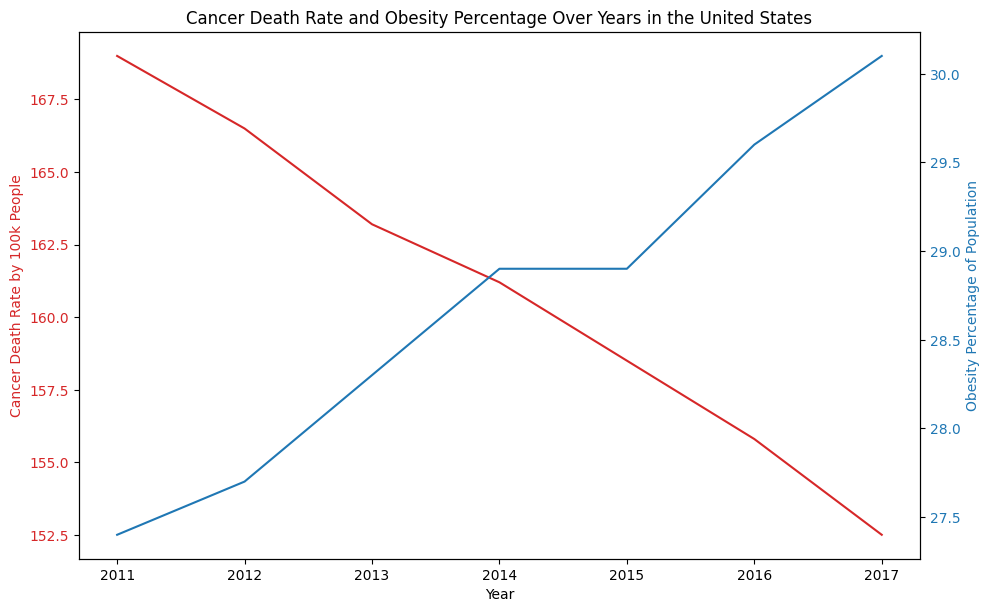

In [69]:
#Visual 1 - FILL IN
# Filter the dataframe for the United States
filtered_df = cancer_obesity[cancer_obesity['state'] == 'United States']

# Plotting the data
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Year')
ax1.set_ylabel('Cancer Death Rate by 100k People', color=color)
ax1.plot(filtered_df['year'], filtered_df['cancer_death_rate_by_100k_people'], color=color, label='Cancer Death Rate by 100k People')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Obesity Percentage of Population', color=color)
ax2.plot(filtered_df['year'], filtered_df['obesity_pct_pop'], color=color, label='Obesity Percentage of Population')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Cancer Death Rate and Obesity Percentage Over Years in the United States')
plt.show()


*Answer to research question:* It appears that the US rate of cancer deaths has fallen steadily from 2011 to 2017, while the US percentage of the population with obesity has increased at nearly the same rate. This would lead one to think that there is a negative realtionship between obesity and cancer related deaths.

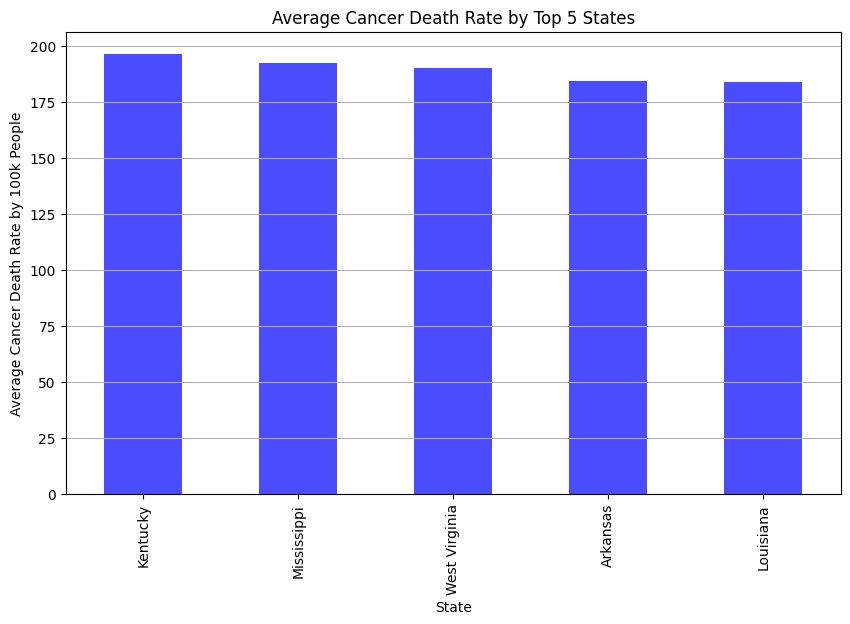

In [70]:

avg_death_rate = cancer_obesity.groupby('state')['cancer_death_rate_by_100k_people'].mean()

# Select the top 5 states by average cancer death rate
top_5_states = avg_death_rate.nlargest(5)

# Plotting
plt.figure(figsize=(10, 6))

top_5_states.plot(kind='bar', alpha=0.7, color='blue')

plt.xlabel('State')
plt.ylabel('Average Cancer Death Rate by 100k People')
plt.title('Average Cancer Death Rate by Top 5 States')
plt.grid(axis='y')
plt.show()


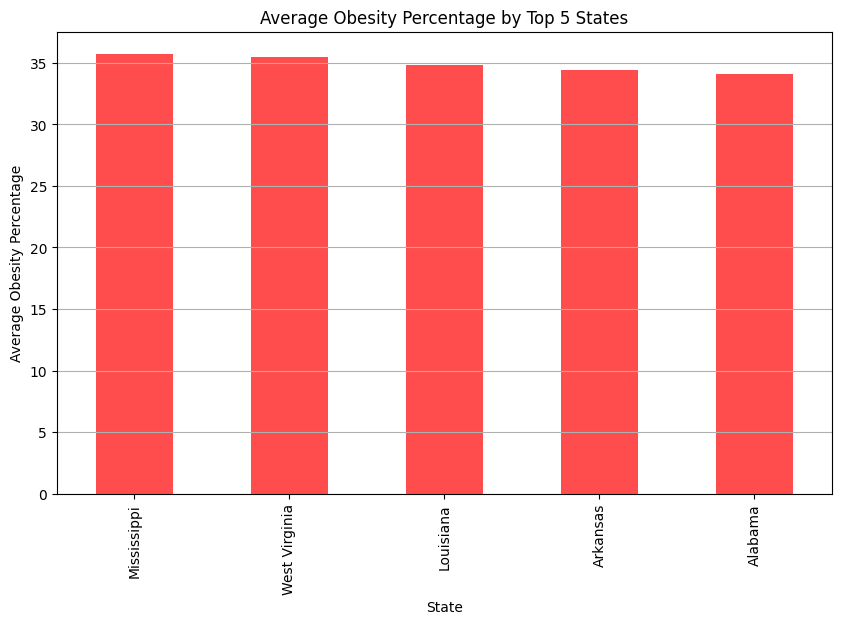

In [71]:
avg_obesity_rate = cancer_obesity.groupby('state')['obesity_pct_pop'].mean()

# Select the top 5 states by average cancer death rate
top_5_states = avg_obesity_rate.nlargest(5)

# Plotting
plt.figure(figsize=(10, 6))

top_5_states.plot(kind='bar', alpha=0.7, color='red')

plt.xlabel('State')
plt.ylabel('Average Obesity Percentage')
plt.title('Average Obesity Percentage by Top 5 States')
plt.grid(axis='y')
plt.show()


*Answer to research question:* Looking at the above two bar charts for the Top 5 States for Average Obesity Percentage and Average Cancer Death Rate, Mississippi, West Virginia, Louisiana, and Arkansas are in the top 5 of both charts. This suggests that there may be a correlation positive between obesity and cancer related deaths. More analysis is needed to comfirm either positive or negative correlation.

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

#### Answer:
##### If I had more time, I would be interested in examining some of the stratification categories from the  Nutrition__Physical_Activity__and_Obesity_-_Behavioral_Risk_Factor_Surveillance_System.csv dataset. I would be interested in how race and income play a part in cancer realted deaths. I would also like to further explore possible correaltions between new cancer diagnosises and obesity, due to constant advances in cancer treatment. I would have to find at least one other dataset, clean it and merge it with the other cleaned datasets to explore any possible correaltion between new cancer diagnosises and obesity.   